In [1]:
import os
import numpy as np
import imageio
import time
from PARAMETRES import *
from binarisation import binarisation
from distance import distance
from distribution import distribution
from calculangle import calculangle
from dessinexport import dessinexport, select_and_plot_files
from prolong_nd import (
    simple_closing,
    multi_angle_closing,
    watershed_and_edge_prolong,
    watershed_grains_pro,
)
from matplotlib import pyplot as plt
from skimage import morphology, segmentation, feature
from scipy import ndimage as ndi
import tkinter as tk
from tkinter import filedialog

# Detailed Process Explanation

## Binarization Processes

This section performs a multi-step binarization process to identify Nd-rich regions in the input images:

1. **Input Preparation**:
   - Converts the input image to grayscale if needed
   - Handles both float (0-1) and uint8 (0-255) input formats

2. **Background Correction**:
   - Applies Gaussian blur to estimate the background
   - Subtracts the background from the original image
   - Normalizes the result to maintain proper contrast

3. **CLAHE Enhancement**:
   - Uses Contrast Limited Adaptive Histogram Equalization (CLAHE)
   - Improves local contrast while preventing over-amplification
   - Helps reveal subtle features in the image

4. **Adaptive Thresholding**:
   - Applies Gaussian adaptive thresholding
   - Creates a binary image where Nd-rich regions are white
   - Automatically adjusts threshold based on local image content

5. **Morphological Cleanup**:
   - Performs closing operations to fill small holes in Nd-rich regions
   - Performs opening operations to remove small isolated white specks
   - Ensures clean, well-defined regions for analysis

The result is a binary mask where:
- White (1) represents Nd-rich regions
- Black (0) represents the matrix material

## Angle Calculation Processes

For cross-sections (when "T" is in type_str), the code performs:

1. **Binarization** (same as above)

2. **Angle Calculation**:
   - Uses the `calculangle()` function
   - Computes image gradients
   - Calculates structure tensors
   - Determines local orientation angles
   - Classifies angles into bins
   - Computes angle distribution

3. **Outputs**:
   - `M_angle`: Angle map (each pixel has an orientation angle)
   - `Classes`: Angle bins (likely -90° to +90°)
   - `distri`: Distribution of angles in each bin

The angle calculation is more computationally intensive and is only performed for cross-section images.

In [ ]:
step = 1  # adjust as needed
global_start = time.perf_counter()
print("🟢 Starting image analysis...")

for ech in range(len(ECHTS)):  # For each sample
    echt = ECHTS[ech]
    print(f"\n📦 Processing sample {ech+1}/{len(ECHTS)}: {echt}")
    nbtypes = len(TYPES) // 3

    for typ in range(nbtypes):  # For each type/depth
        type_str = TYPES[typ * 3 : typ * 3 + 3]
        # Last type can be 'TR' (2 letters only)
        if typ == nbtypes - 1:
            type_str = type_str[:2]
        nbrephotos = NBPHOTOS[5 * ech + typ]
        print(f"  🔹 Type {typ+1}/{nbtypes}: {type_str}, {nbrephotos} photo(s)")

        for fich in range(1, nbrephotos + 1):  # For each image
            photo = f"{nomanip}{echt}-{type_str}{fich}"
            chePH = os.path.join(cheM, photo)
            cheRES = os.path.join(cheM, "Résultats", f"{photo}.xlsx")
            # Ensure results directory exists
            os.makedirs(os.path.dirname(cheRES), exist_ok=True)
            img_path = chePH + ".TIF"
            if not os.path.exists(img_path):
                print(f"    ⚠️  Image not found: {img_path}")
                continue
            print(f"    🖼️  Processing photo {fich}/{nbrephotos}: {img_path}")

            M = imageio.v2.imread(img_path).astype(np.float64) / 255.0
            hauteur, largeur = M.shape[:2]
            # For quick tests increase step, for precision keep at 1
            plagex = np.arange(1, hauteur, step)
            plagey = np.arange(1, largeur, step)

            if "T" not in type_str:  # face views → spacing calculation
                print("      ⚙️  Running binarisation...")
                M_bin = binarisation(
                    M,
                    clip_limit=2.0,
                    tile_grid_size=(8, 8),
                    blur_kernel=101,
                    block_size=51,
                    C=3,
                    kernel_size=2,
                    n_close=1,
                    n_open=1,
                )

                # 1️⃣ Binarized
                imageio.imwrite(
                    f"{chePH}-binarized.TIF", (M_bin * 255).astype(np.uint8)
                )

                # 2️⃣ Morphological closing
                M_bin_closed = simple_closing(M_bin, disk_radius=3)
                imageio.imwrite(
                    f"{chePH}-closed.TIF", (M_bin_closed * 255).astype(np.uint8)
                )

                # 3️⃣ Directional closing
                M_bin_dir = multi_angle_closing(
                    M_bin, line_length=3, angles=np.arange(0, 180, 1)
                )
                imageio.imwrite(
                    f"{chePH}-directional_closing.TIF",
                    (M_bin_dir * 255).astype(np.uint8),
                )

                # 4️⃣ Watershed + edge prolongation
                M_bin_prolonged, labels = watershed_and_edge_prolong(
                    M_bin, min_distance=1, min_size=50, edge_width=2
                )
                imageio.imwrite(
                    f"{chePH}-prolonged.TIF", (M_bin_prolonged * 255).astype(np.uint8)
                )

                # --- Prepare binarized variants
                bin_variants = {
                    "Binarized": M_bin,
                    "Closed": M_bin_closed,
                    "Directional Closing": M_bin_dir,
                    "Prolonged": M_bin_prolonged,
                }

                # Dictionaries to store watershed outputs
                dil_eroded_masks = {}
                grain_masks = {}
                grain_labels_dict = {}

                # --- Run watershed grains on each variant
                for name, img in bin_variants.items():
                    mask, labels, dil_eroded = watershed_grains_pro(
                        img,  # use each variant
                        pre_dilate_steps=2,
                        pre_erode_steps=1,
                        selem_radius=1,
                        marker_distance=5,
                        min_grain_size=20,
                        edge_smooth=0,
                        return_preprocessed=True,
                    )
                    dil_eroded_masks[name] = dil_eroded
                    grain_masks[name] = mask
                    grain_labels_dict[name] = labels

                # --- Summary figure: 4 rows (original mask, dilated/eroded, grain mask, labels)
                n_variants = len(bin_variants)
                fig, axes = plt.subplots(4, n_variants, figsize=(5 * n_variants, 16))
                # Flatten axes for indexing
                axes = axes if axes.ndim == 2 else axes.reshape(4, n_variants)

                # 1️⃣ Top row: original Nd-rich masks
                for i, name in enumerate(bin_variants.keys()):
                    axes[0, i].imshow(bin_variants[name], cmap="gray")
                    axes[0, i].set_title(f"{name} Mask")
                    axes[0, i].axis("off")

                # 2️⃣ Second row: masks after dilation → erosion
                for i, name in enumerate(bin_variants.keys()):
                    axes[1, i].imshow(dil_eroded_masks[name], cmap="gray")
                    axes[1, i].set_title(f"{name} Dilated/Eroded")
                    axes[1, i].axis("off")

                # 3️⃣ Third row: grain masks
                for i, name in enumerate(bin_variants.keys()):
                    axes[2, i].imshow(grain_masks[name], cmap="gray")
                    axes[2, i].set_title(f"{name} Grain Mask")
                    axes[2, i].axis("off")

                # 4️⃣ Bottom row: labeled grains
                for i, name in enumerate(bin_variants.keys()):
                    axes[3, i].imshow(grain_labels_dict[name], cmap="tab20")
                    axes[3, i].set_title(f"{name} Labels")
                    axes[3, i].axis("off")

                plt.tight_layout()
                plt.savefig(f"{chePH}-mask_dilated_grains_labels.png", dpi=200)
                plt.close(fig)

                # Select the image used for measurements
                M_for_measure = M_bin_prolonged  # choose which binary mask to use

                print("      ⚙️  Running distance calculation...")
                D, DM = distance(M_for_measure, plagex, plagey)

                print("      ⚙️  Running distribution calculation...")
                Classes, distri = distribution(DM)

                print(f"      💾 Exporting results to {cheRES}")
                dessinexport(M_for_measure, DM, Classes, distri, chePH, cheRES, photo)

                # --- Watershed grains
                M_grain_mask, grain_labels = watershed_grains_pro(
                    M_bin,
                    pre_dilate_steps=2,
                    pre_erode_steps=1,
                    selem_radius=1,
                    marker_distance=5,
                    min_grain_size=50,
                    edge_smooth=1,
                )

                # Save outputs for inspection
                imageio.imwrite(
                    f"{chePH}-grains_mask.TIF", (M_grain_mask * 255).astype(np.uint8)
                )
                plt.imsave(f"{chePH}-grains_labels.TIFF", grain_labels, cmap="tab20")

            else:  # cross-sections → angle calculation
                print("      ⚙️  Running binarisation...")
                M_bin = binarisation(
                    M,
                    clip_limit=2.0,
                    tile_grid_size=(8, 8),
                    blur_kernel=101,
                    block_size=51,
                    C=3,
                    kernel_size=2,
                    n_close=1,
                    n_open=1,
                )

                print("      ⚙️  Running angle calculation...")
                start = time.perf_counter()
                M_angle, Classes, distri = calculangle(
                    M_bin, smooth_sigma=0.3, tensor_blur=15, eps=1e-12
                )
                elapsed = time.perf_counter() - start
                print(f"⏱️ Orientation calculation: {elapsed:.2f} s")

                print(f"      💾 Exporting results to {cheRES}")
                dessinexport(
                    M_bin, M_angle, Classes, distri, chePH, cheRES, photo
                )  # distribution may not apply



global_elapsed = time.perf_counter() - global_start
print(f"\n⏱️ Total elapsed time: {global_elapsed:.2f} s")
print("\n✅ Image analysis complete. Results saved in the 'Résultats' folder.")

🟢 Starting image analysis...

📦 Processing sample 1/1: A
  🔹 Type 1/5: RRR, 0 photo(s)
  🔹 Type 2/5: RRA, 0 photo(s)
  🔹 Type 3/5: RAA, 0 photo(s)
  🔹 Type 4/5: AAA, 0 photo(s)
  🔹 Type 5/5: TR, 1 photo(s)
    🖼️  Processing photo 1/1: C:/Users/MB232649/Documents/M.Boidot Local/Informatique/Projets-info/2025-Nd_Rich_Spacing/Nd_spacing/SC18\18A-TR1.TIF
      ⚙️  Running binarisation...
      ⚙️  Running angle calculation...
⏱️ Orientation calculation: 0.04 s
      💾 Exporting results to C:/Users/MB232649/Documents/M.Boidot Local/Informatique/Projets-info/2025-Nd_Rich_Spacing/Nd_spacing/SC18\Résultats\18A-TR1.xlsx
✅ Exported: 18A-TR1
   ├─ C:/Users/MB232649/Documents/M.Boidot Local/Informatique/Projets-info/2025-Nd_Rich_Spacing/Nd_spacing/SC18\18A-TR1-original_binary.TIF
   ├─ C:/Users/MB232649/Documents/M.Boidot Local/Informatique/Projets-info/2025-Nd_Rich_Spacing/Nd_spacing/SC18\18A-TR1-processed_image.TIF
   ├─ C:/Users/MB232649/Documents/M.Boidot Local/Informatique/Projets-info/2025-

In [3]:
# -*- coding: utf-8 -*-
"""
Comparison of Angle Calculation Methods
--------------------------------------
This script compares the original MATLAB-style angle calculation with the vectorized structure tensor approach.
It uses images generated in the main analysis loop with a single binarization method.
"""
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
from calculangle import calculangle
from calculangle_matlab import calculangle_matlab
from dessinexport import dessinexport

# Initialize comparison results storage
comparison_results = []

# Create directories for results if they don't exist
results_dir = os.path.join(cheM, "Résultats")
matlab_dir = os.path.join(results_dir, "matlab_results")
tensor_dir = os.path.join(results_dir, "tensor_results")

os.makedirs(matlab_dir, exist_ok=True)
os.makedirs(tensor_dir, exist_ok=True)

# Process the images and compare angle calculation methods
for ech in range(len(ECHTS)):  # For each sample
    echt = ECHTS[ech]
    print(f"\n📦 Processing sample {ech+1}/{len(ECHTS)}: {echt}")
    nbtypes = len(TYPES) // 3

    for typ in range(nbtypes):  # For each type/depth
        type_str = TYPES[typ * 3 : typ * 3 + 3]
        # Last type can be 'TR' (2 letters only)
        if typ == nbtypes - 1:
            type_str = type_str[:2]
        nbrephotos = NBPHOTOS[5 * ech + typ]
        print(f"  🔹 Type {typ+1}/{nbtypes}: {type_str}, {nbrephotos} photo(s)")

        for fich in range(1, nbrephotos + 1):  # For each image
            photo = f"{nomanip}{echt}-{type_str}{fich}"
            chePH = os.path.join(cheM, photo)
            cheRES = os.path.join(cheM, "Résultats", f"{photo}.xlsx")

            img_path = chePH + ".TIF"
            if not os.path.exists(img_path):
                print(f"    ⚠️  Image not found: {img_path}")
                continue

            print(f"    🖼️  Processing photo {fich}/{nbrephotos}: {img_path}")

            # Skip face views (only process cross-sections)
            if "T" in type_str:  # cross-sections → angle calculation
                # Load the original image
                M = imageio.v2.imread(img_path).astype(np.float64) / 255.0

                # Perform binarization (CLAHE + BG correction + adaptive thresholding + OC)
                print("      ⚙️  Running binarisation...")
                M_bin = binarisation(
                    M,
                    clip_limit=2.0,
                    tile_grid_size=(8, 8),
                    blur_kernel=101,
                    block_size=51,
                    C=3,
                    kernel_size=2,
                    n_close=1,
                    n_open=1,
                )

                # Save the binarized image
                imageio.imwrite(
                    f"{chePH}-binarized_for_comparison.TIF", (M_bin * 255).astype(np.uint8)
                )

                # Calculate angles using both methods on the same image
                print("      ⚙️  Running MATLAB-style angle calculation...")
                DM_matlab, Classes_matlab, distri_matlab = calculangle_matlab(M_bin)

                print("      ⚙️  Running vectorized structure tensor angle calculation...")
                DM_tensor, Classes_tensor, distri_tensor = calculangle(
                    M_bin,
                    smooth_sigma=0.3,
                    tensor_blur=15,
                    eps=1e-12
                )

                # Store results for comparison
                comparison_results.append({
                    'sample': echt,
                    'type': type_str,
                    'photo': fich,
                    'DM_matlab': DM_matlab,
                    'DM_tensor': DM_tensor,
                    'Classes': Classes_matlab,
                    'distri_matlab': distri_matlab,
                    'distri_tensor': distri_tensor,
                    'M_bin': M_bin
                })

                # Create a figure to compare results
                plt.figure(figsize=(15, 10))

                # Plot the original binary image
                plt.subplot(3, 2, 1)
                plt.imshow(M_bin, cmap='gray')
                plt.title('Original Binary Image')
                plt.axis('off')

                # Plot the MATLAB-style angle map
                plt.subplot(3, 2, 2)
                plt.imshow(DM_matlab, cmap='viridis', vmin=-90, vmax=90)
                plt.title('MATLAB-style Angle Map')
                plt.colorbar(label='Angle (degrees)')
                plt.axis('off')

                # Plot the structure tensor angle map
                plt.subplot(3, 2, 3)
                plt.imshow(DM_tensor, cmap='viridis', vmin=-90, vmax=90)
                plt.title('Structure Tensor Angle Map')
                plt.colorbar(label='Angle (degrees)')
                plt.axis('off')

                # Plot the MATLAB-style distribution
                plt.subplot(3, 2, 4)
                plt.plot(Classes_matlab, distri_matlab, 'r-', linewidth=2)
                plt.title('MATLAB-style Angle Distribution')
                plt.xlabel('Depth')
                plt.ylabel('Deviation from Vertical (90 - |angle|)')
                plt.grid(True)

                # Plot the structure tensor distribution
                plt.subplot(3, 2, 5)
                plt.plot(Classes_tensor, distri_tensor, 'b-', linewidth=2)
                plt.title('Structure Tensor Angle Distribution')
                plt.xlabel('Depth')
                plt.ylabel('Deviation from Vertical (90 - |angle|)')
                plt.grid(True)

                # Plot the difference between distributions
                plt.subplot(3, 2, 6)
                plt.plot(Classes_matlab, distri_matlab - distri_tensor, 'g-', linewidth=2)
                plt.title('Difference in Angle Distributions')
                plt.xlabel('Depth')
                plt.ylabel('Difference (MATLAB - Tensor)')
                plt.grid(True)

                plt.tight_layout()
                plt.suptitle(f'Comparison for {echt}-{type_str}{fich}')
                plt.savefig(f"{chePH}-angle_comparison.png", dpi=200)
                plt.close()

                # Print some statistics
                print("\nComparison Statistics:")
                print(f"MATLAB method mean angle: {np.nanmean(DM_matlab[M_bin > 0.5]):.2f}°")
                print(f"Tensor method mean angle: {np.nanmean(DM_tensor[M_bin > 0.5]):.2f}°")
                print(f"MATLAB method std angle: {np.nanstd(DM_matlab[M_bin > 0.5]):.2f}°")
                print(f"Tensor method std angle: {np.nanstd(DM_tensor[M_bin > 0.5]):.2f}°")
                print(f"Mean difference in distributions: {np.mean(distri_matlab - distri_tensor):.2f}")

                # Create proper file paths for Excel exports
                matlab_res_path = os.path.join(matlab_dir, f"{photo}_matlab.xlsx")
                tensor_res_path = os.path.join(tensor_dir, f"{photo}_tensor.xlsx")

                # Export results for further analysis
                dessinexport(M_bin, DM_matlab, Classes_matlab, distri_matlab, chePH, matlab_res_path, f"{photo}_matlab")
                dessinexport(M_bin, DM_tensor, Classes_tensor, distri_tensor, chePH, tensor_res_path, f"{photo}_tensor")

# After processing all images, you can analyze the comparison results
print("\nComparison of all angle calculation methods complete.")
print(f"Processed {len(comparison_results)} images.")


📦 Processing sample 1/1: A
  🔹 Type 1/5: RRR, 0 photo(s)
  🔹 Type 2/5: RRA, 0 photo(s)
  🔹 Type 3/5: RAA, 0 photo(s)
  🔹 Type 4/5: AAA, 0 photo(s)
  🔹 Type 5/5: TR, 1 photo(s)
    🖼️  Processing photo 1/1: C:/Users/MB232649/Documents/M.Boidot Local/Informatique/Projets-info/2025-Nd_Rich_Spacing/Nd_spacing/SC18\18A-TR1.TIF
      ⚙️  Running binarisation...
      ⚙️  Running MATLAB-style angle calculation...
      ⚙️  Running vectorized structure tensor angle calculation...

Comparison Statistics:
MATLAB method mean angle: -6.94°
Tensor method mean angle: 15.13°
MATLAB method std angle: 49.18°
Tensor method std angle: 54.31°
Mean difference in distributions: -0.99
✅ Exported: 18A-TR1_matlab
   ├─ C:/Users/MB232649/Documents/M.Boidot Local/Informatique/Projets-info/2025-Nd_Rich_Spacing/Nd_spacing/SC18\18A-TR1-original_binary.TIF
   ├─ C:/Users/MB232649/Documents/M.Boidot Local/Informatique/Projets-info/2025-Nd_Rich_Spacing/Nd_spacing/SC18\18A-TR1-processed_image.TIF
   ├─ C:/Users/MB2326

# Post-processing: Select and Plot Superimposed Data

Run this cell to select and plot data from multiple XLSX files.


📊 Post-processing: Select and plot superimposed data
--------------------------------------------------


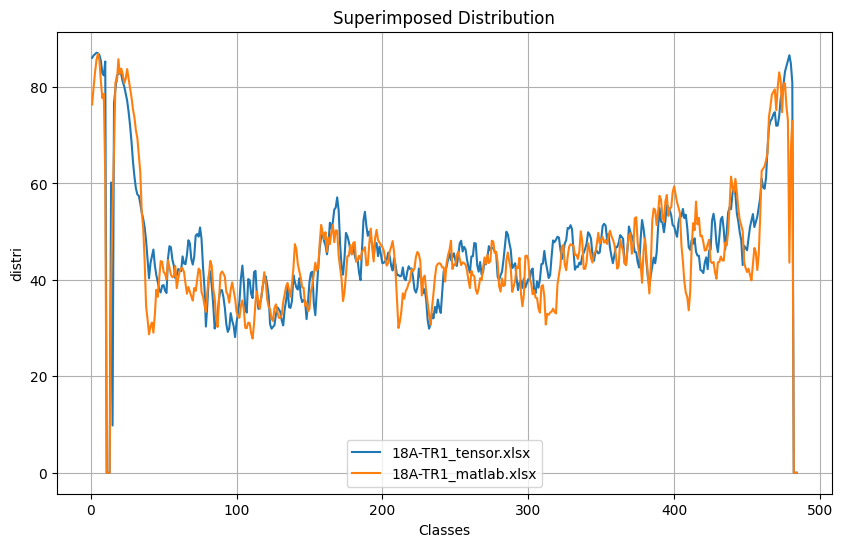

In [6]:
print("\n📊 Post-processing: Select and plot superimposed data")
print("--------------------------------------------------")


root = tk.Tk()
root.withdraw()  # Hide the main window
results_dir = os.path.join(cheM, "Résultats")
select_and_plot_files(results_dir)